In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
consolidated = pd.read_csv(
    '/content/drive/MyDrive/IT5006_Olist_Project/smartcommerce_consolidated.csv'
)
print(consolidated.shape)
print(consolidated.columns.tolist())

(112650, 25)
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name_english', 'product_weight_g', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_state', 'customer_city', 'seller_state', 'order_date', 'year_month', 'year', 'month', 'day_of_week', 'delivery_days', 'is_on_time', 'item_revenue']


In [ ]:
consolidated.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,product_weight_g,customer_id,...,customer_city,seller_state,order_date,year_month,year,month,day_of_week,delivery_days,is_on_time,item_revenue
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,650.0,3ce436f183e68e07877b285a838db11a,...,campos dos goytacazes,SP,2017-09-13,2017-09,2017,9,Wednesday,7.0,True,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,30000.0,f6dd3ec061db4e3987629fe6b26e5cce,...,santa fe do sul,SP,2017-04-26,2017-04,2017,4,Wednesday,16.0,True,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,furniture_decor,3050.0,6489ae5e4333f3693df5ad4372dab6d3,...,para de minas,MG,2018-01-14,2018-01,2018,1,Sunday,7.0,True,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumery,200.0,d4eb9395c8c0431ee92fce09860c5a06,...,atibaia,SP,2018-08-08,2018-08,2018,8,Wednesday,6.0,True,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,garden_tools,3750.0,58dbd0b2d70206bf40e62cd34e84d795,...,varzea paulista,PR,2017-02-04,2017-02,2017,2,Saturday,25.0,True,218.04


In [ ]:
print("Rows:", len(consolidated))
print("Unique orders:", consolidated['order_id'].nunique())

Rows: 112650
Unique orders: 98666


In [ ]:
df = pd.read_csv(
    '/content/drive/MyDrive/IT5006_Olist_Project/smartcommerce_consolidated.csv',
    parse_dates=[
        'order_purchase_timestamp',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]
)

In [ ]:
print("Rows:", len(df))
print("Unique orders:", df['order_id'].nunique())

Rows: 112650
Unique orders: 98666


In [ ]:
order_level = (
    df.groupby('order_id')
      .agg(
          order_status=('order_status', 'first'),
          purchase_time=('order_purchase_timestamp', 'first'),
          delivered_time=('order_delivered_customer_date', 'first'),
          estimated_delivery=('order_estimated_delivery_date', 'first'),
          customer_state=('customer_state', 'first'),
          seller_state=('seller_state', 'first'),

          total_price=('price', 'sum'),
          total_freight=('freight_value', 'sum'),
          item_count=('order_item_id', 'count'),
          avg_product_weight=('product_weight_g', 'mean'),

          product_category=('product_category_name_english', 'first')
      )
      .reset_index()
)

Rearrange the data by order-level.

In [ ]:
print(order_level.shape)

(98666, 12)


In [ ]:
delivered = order_level[
    order_level['delivered_time'].notna()
].copy()

print(delivered.shape)

(96476, 12)


Keep the records of really delivered.

In [ ]:
delivered['is_late'] = (
    delivered['delivered_time'] >
    delivered['estimated_delivery']
).astype(int)

In [ ]:
delivered['is_late'].value_counts()

,count
is_late,
0,88649
1,7827


In [ ]:
delivered['is_late'].value_counts(normalize=True) * 100

,proportion
is_late,
0,91.887101
1,8.112899


what features are related to late delivery? Test in order:
1. Temporal
2. Geography
3. Freight / price / weight
4. Product category
5. Item count


1. Temporal
*   monthly v.s weekly



In [ ]:
delivered['purchase_month'] = delivered['purchase_time'].dt.to_period('M').astype(str)
delivered['purchase_weekday'] = delivered['purchase_time'].dt.day_name()

In [ ]:
late_by_month = (
    delivered.groupby('purchase_month')
    .agg(
        late_rate=('is_late', 'mean'),
        order_count=('order_id', 'count')
    )
    .reset_index()
)

late_by_month['late_rate_pct'] = late_by_month['late_rate'] * 100

late_by_month

,purchase_month,late_rate,order_count,late_rate_pct
0,2016-09,1.000000,1,100.000000
1,2016-10,0.011111,270,1.111111
2,2016-12,0.000000,1,0.000000
3,2017-01,0.030667,750,3.066667
4,2017-02,0.032063,1653,3.206292
5,2017-03,0.055774,2546,5.577376
6,2017-04,0.078593,2303,7.859314
7,2017-05,0.036107,3545,3.610719
8,2017-06,0.038596,3135,3.859649
9,2017-07,0.034349,3872,3.434917


In [ ]:
late_by_weekday = (
    delivered.groupby('purchase_weekday')
    .agg(
        late_rate=('is_late', 'mean'),
        order_count=('order_id', 'count')
    )
)

late_by_weekday['late_rate_pct'] = late_by_weekday['late_rate'] * 100

late_by_weekday.sort_values('late_rate_pct', ascending=False)

,late_rate,order_count,late_rate_pct
purchase_weekday,,,
Monday,0.090556,15703,9.055594
Tuesday,0.084892,15502,8.489227
Friday,0.084472,13685,8.447205
Wednesday,0.078015,15074,7.801513
Saturday,0.075976,10556,7.597575
Thursday,0.075688,14322,7.568775
Sunday,0.074867,11634,7.486677


Monthly eda results worth scrutinization.

In [ ]:
late_by_month_plot = late_by_month[
    late_by_month['order_count'] >= 500
]

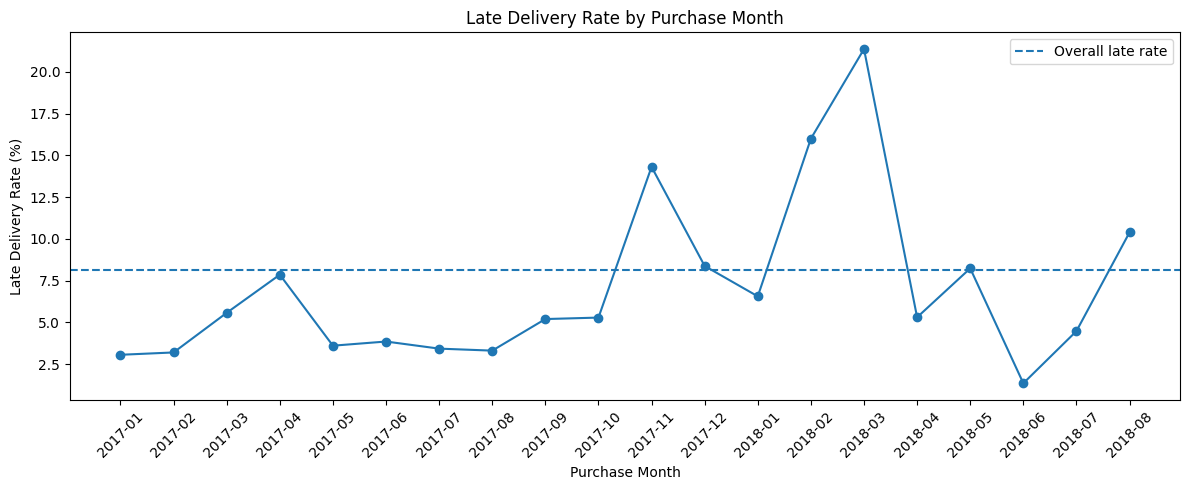

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    late_by_month_plot['purchase_month'],
    late_by_month_plot['late_rate_pct'],
    marker='o'
)

plt.axhline(
    delivered['is_late'].mean() * 100,
    linestyle='--',
    label='Overall late rate'
)

plt.xticks(rotation=45)
plt.xlabel('Purchase Month')
plt.ylabel('Late Delivery Rate (%)')
plt.title('Late Delivery Rate by Purchase Month')
plt.legend()
plt.tight_layout()
plt.show()

Late delivery rates show substantial temporal variation. While the overall late-delivery rate is approximately 8.1%, rates increased sharply in several periods, reaching 14.3% in November 2017, 16.0% in February 2018 and 21.4% in March 2018. This suggests that seasonality and order timing may be useful predictors of late-delivery risk.

2. Geography
*   same state delivery v.s cross-state delivery
*   customer_state delivery

In [ ]:
delivered['same_state'] = (
    delivered['customer_state'] == delivered['seller_state']
).astype(int)

In [ ]:
same_state_summary = (
    delivered.groupby('same_state')
    .agg(
        late_rate=('is_late', 'mean'),
        order_count=('order_id', 'count')
    )
)

same_state_summary['late_rate_pct'] = (
    same_state_summary['late_rate'] * 100
)

same_state_summary

,late_rate,order_count,late_rate_pct
same_state,,,
0,0.092662,61773,9.266184
1,0.060600,34703,6.059995


Cross-state orders showed a higher late-delivery rate (9.27%) than same-state orders (6.06%), suggesting that geographic separation between sellers and customers may contribute to delivery risk.